# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

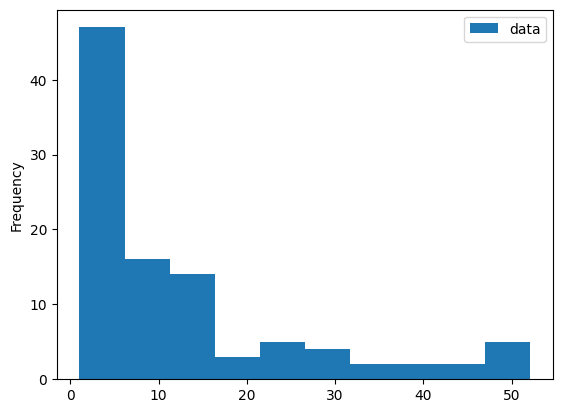

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

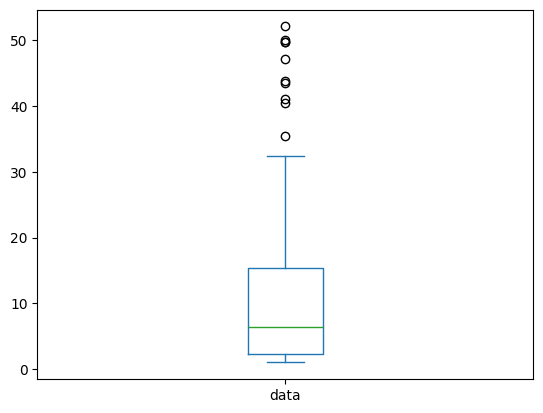

In [3]:
df.plot.box()

The histogram and boxplot both represent the same data, but they emphasize different aspects of the distribution.

A histogram shows the full shape of the distribution. It allows us to see how prices are distributed across ranges, whether the data are skewed, and whether there are clusters of expensive drugs. In this case, the histogram likely shows a right-skewed distribution, meaning a small number of drugs are much more expensive than most others.

A boxplot, on the other hand, summarizes the distribution using quartiles. It clearly shows the median, the interquartile range, and any outliers. This makes it easier to quickly identify how expensive the top 25% of drugs are and whether extreme values are present.

If the administrator wants to understand how expensive drugs compare to the rest of the prices, I would choose the boxplot because it clearly shows the 75th percentile and highlights outliers. However, I would include both plots together for a complete picture.

To improve formatting, I would:

Add axis labels and a clear title

Adjust bin size in the histogram

Use color to emphasize the upper quartile

Add gridlines for readability

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("bank.csv")

# (Optional but helpful) clean column names
df.columns = df.columns.str.strip().str.lower()

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [5]:
df.info()

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB
Numeric columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns: ['job', 'marital', 'educ

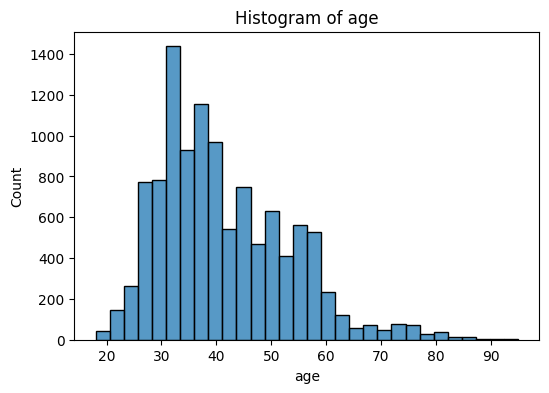

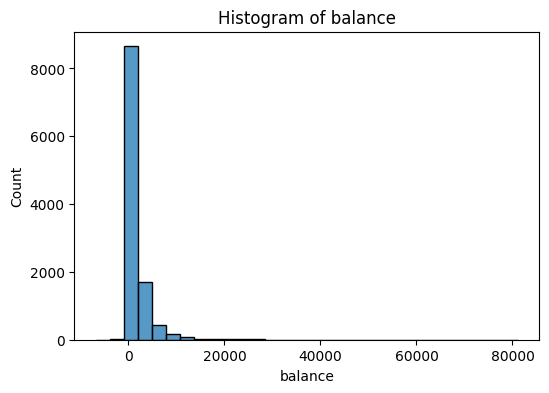

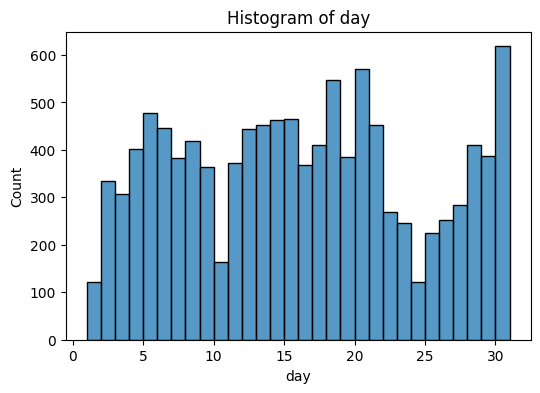

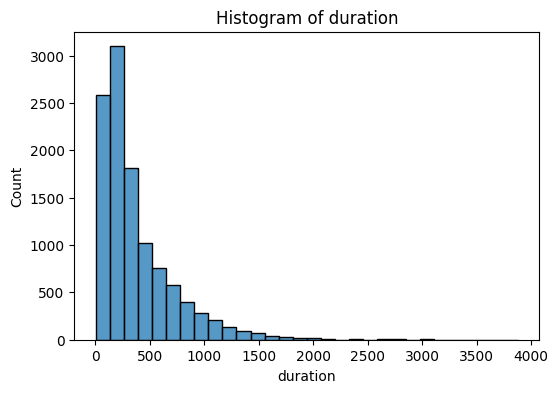

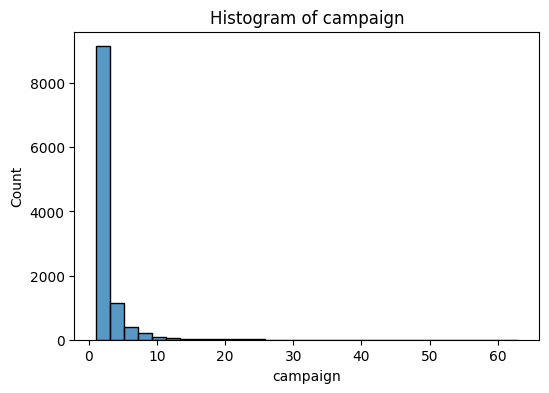

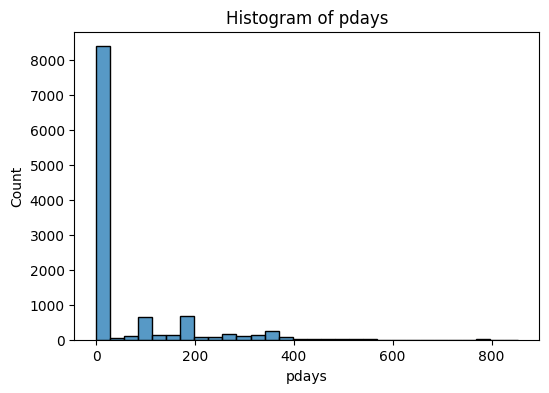

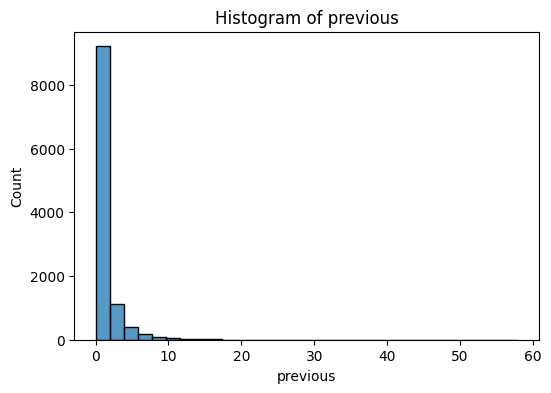

In [6]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

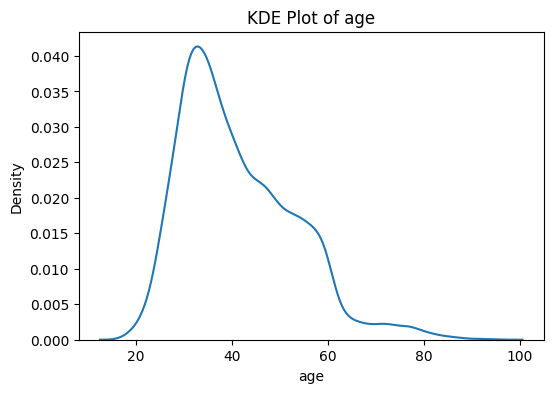

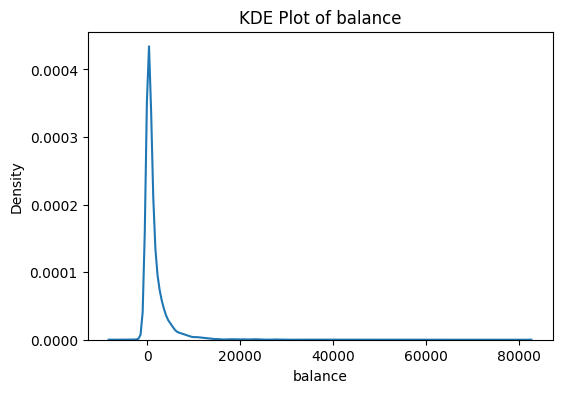

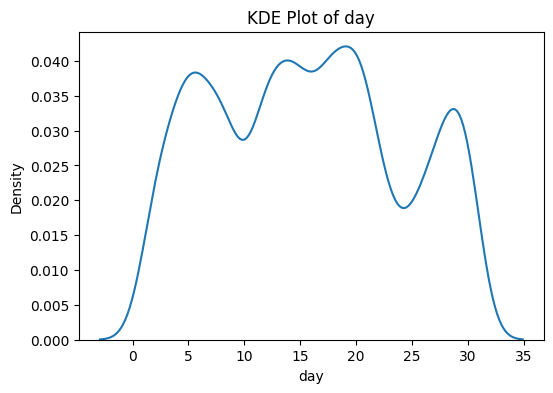

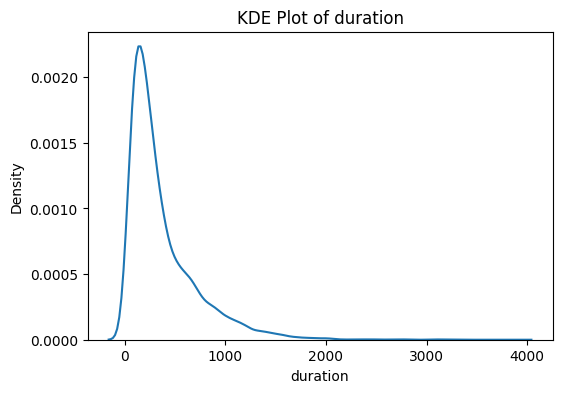

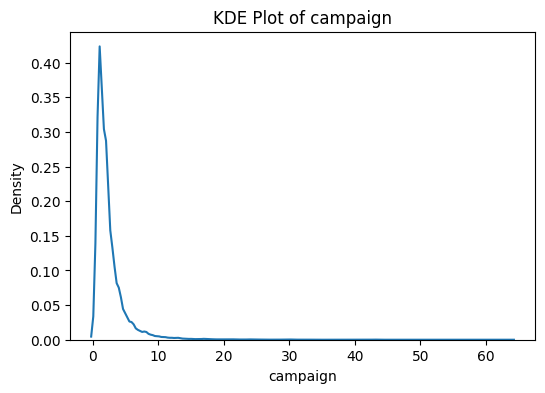

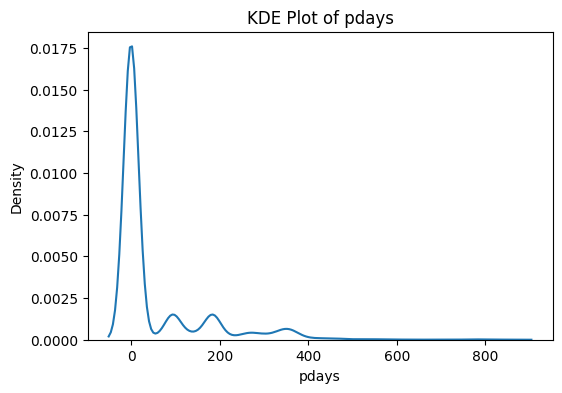

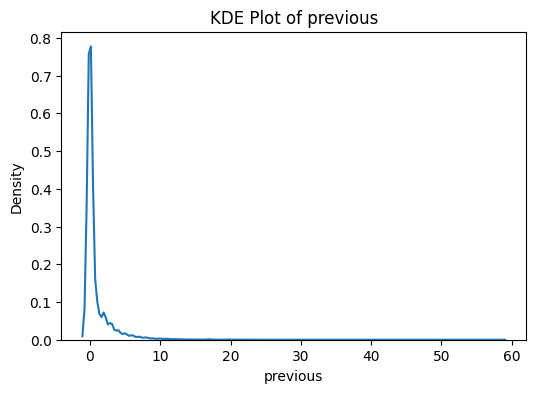

In [7]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df[col])
    plt.title(f"KDE Plot of {col}")
    plt.xlabel(col)
    plt.show()

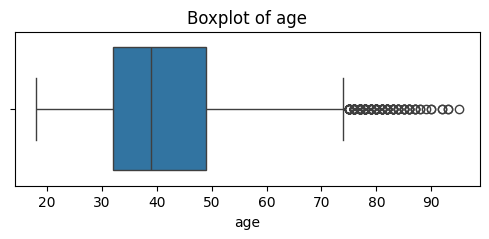

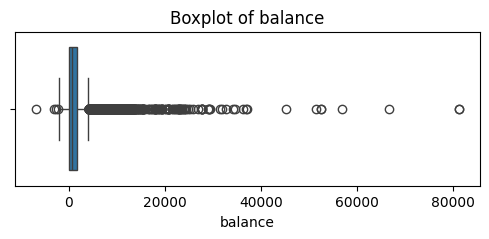

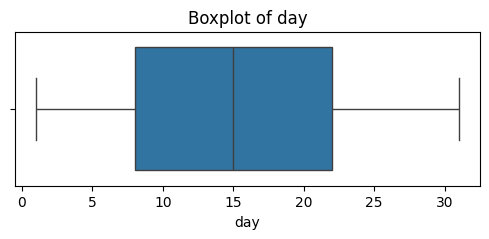

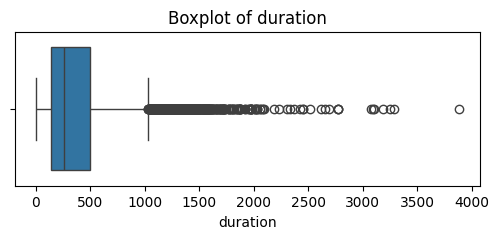

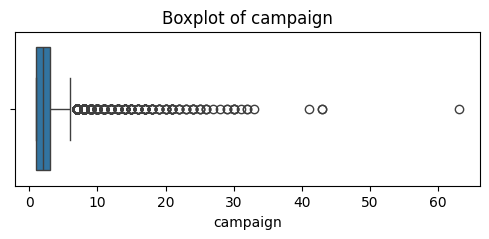

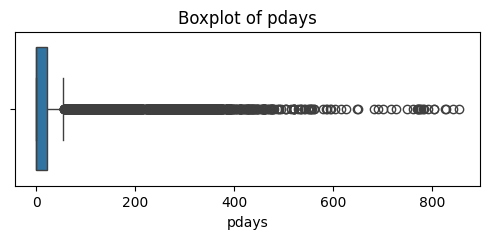

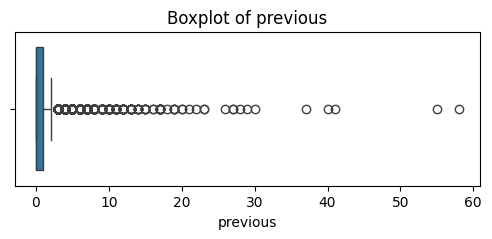

In [8]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

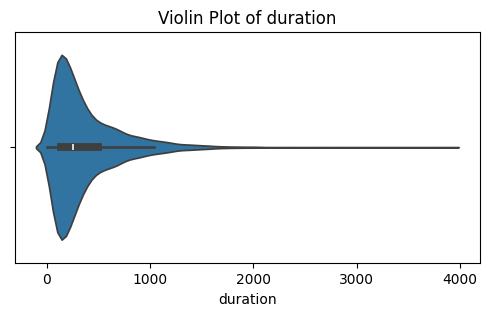

In [9]:
# Violin plots work best one at a time
plt.figure(figsize=(6,3))
sns.violinplot(x=df["duration"])
plt.title("Violin Plot of duration")
plt.show()

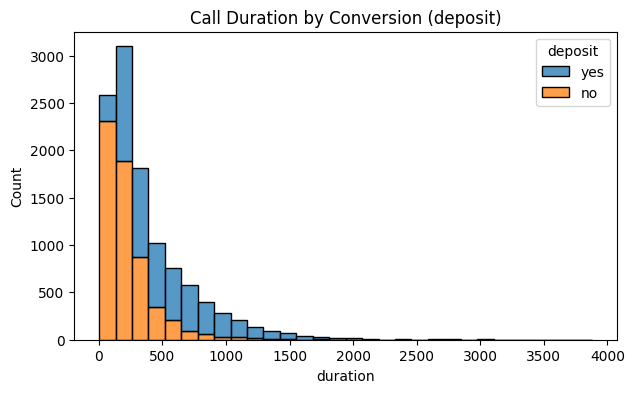

In [10]:
plt.figure(figsize=(7,4))
sns.histplot(data=df, x="duration", hue="deposit", bins=30, multiple="stack")
plt.title("Call Duration by Conversion (deposit)")
plt.xlabel("duration")
plt.show()

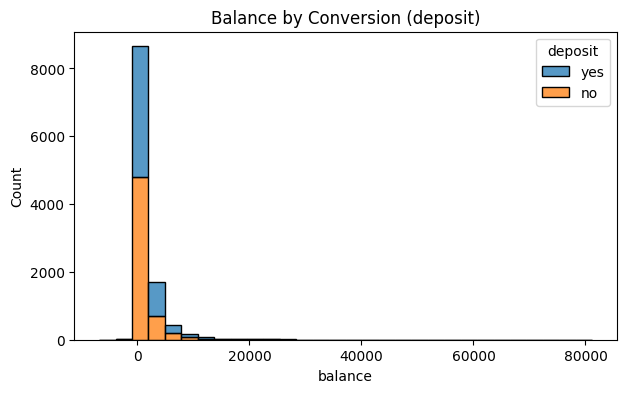

In [11]:
plt.figure(figsize=(7,4))
sns.histplot(data=df, x="balance", hue="deposit", bins=30, multiple="stack")
plt.title("Balance by Conversion (deposit)")
plt.xlabel("balance")
plt.show()

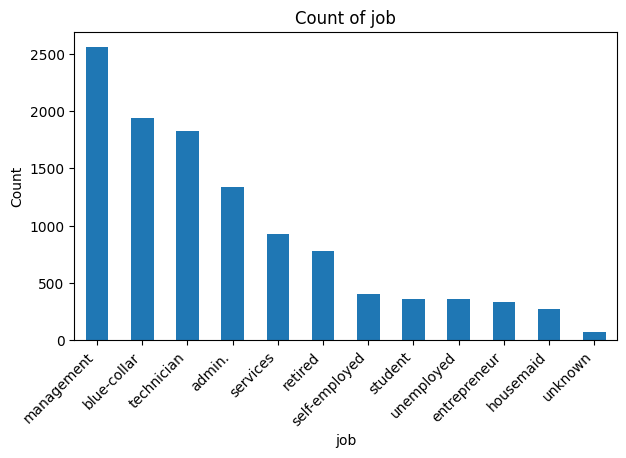

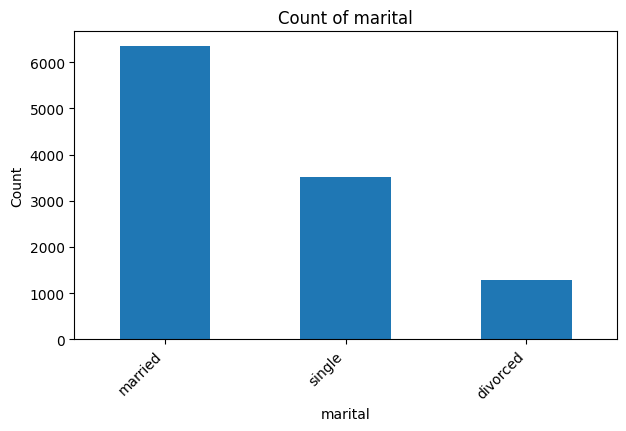

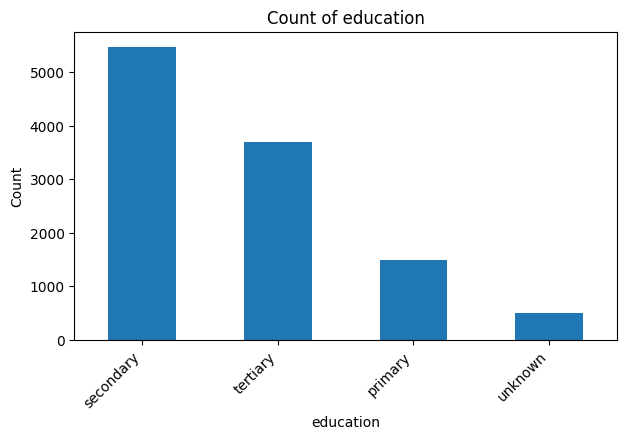

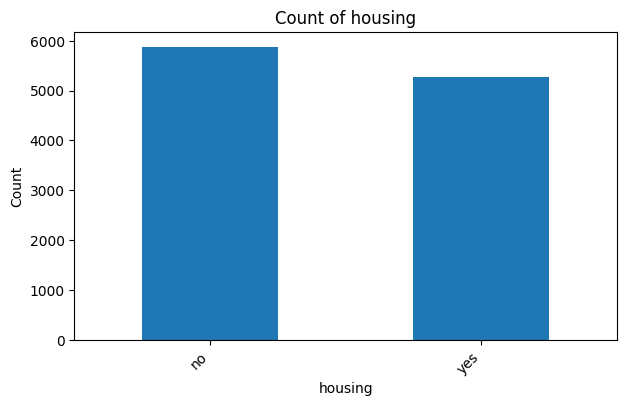

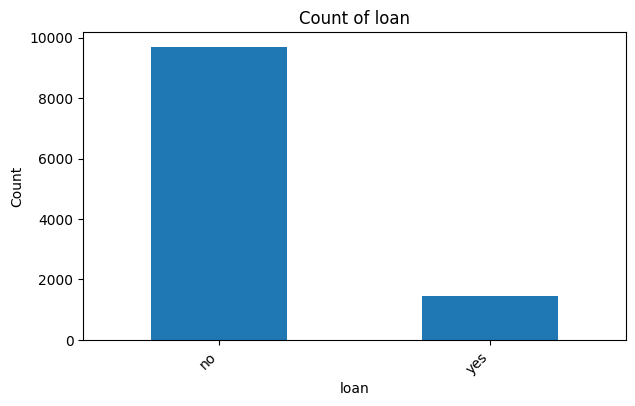

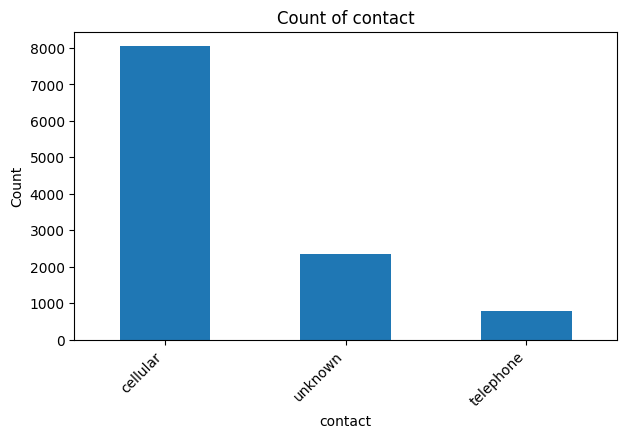

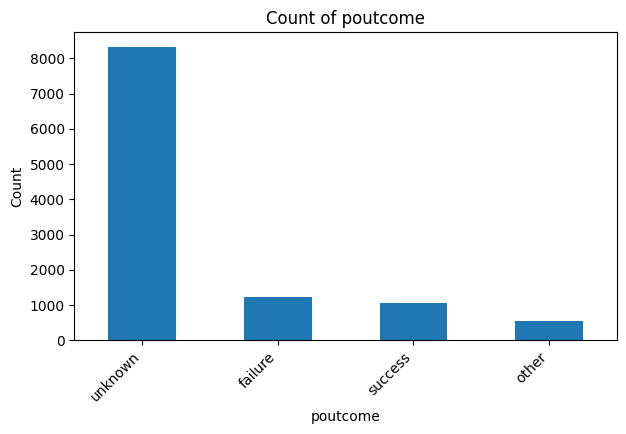

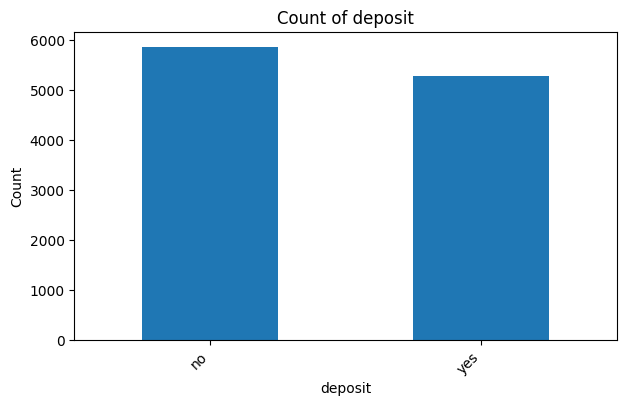

In [12]:
# Pick a few important categorical columns (you can add more)
cat_to_plot = ["job", "marital", "education", "housing", "loan", "contact", "poutcome", "deposit"]

for col in cat_to_plot:
    plt.figure(figsize=(7,4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Count of {col}")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.show()

In [13]:
summary = []

for col in num_cols:
    summary.append({
        "column": col,
        "min": df[col].min(),
        "max": df[col].max(),
        "mean": df[col].mean(),
        "median": df[col].median(),
        "mode": df[col].mode().iloc[0],
        "skew": df[col].skew()
    })

summary_df = pd.DataFrame(summary).set_index("column")
summary_df

,min,max,mean,median,mode,skew
column,,,,,,
age,18,95,41.231948,39.0,31,0.862780
balance,-6847,81204,1528.538524,550.0,0,8.224619
day,1,31,15.658036,15.0,20,0.111330
duration,2,3881,371.993818,255.0,97,2.143695
campaign,1,63,2.508421,2.0,1,5.545578
pdays,-1,854,51.330407,-1.0,-1,2.449986
previous,0,58,0.832557,0.0,0,7.335298


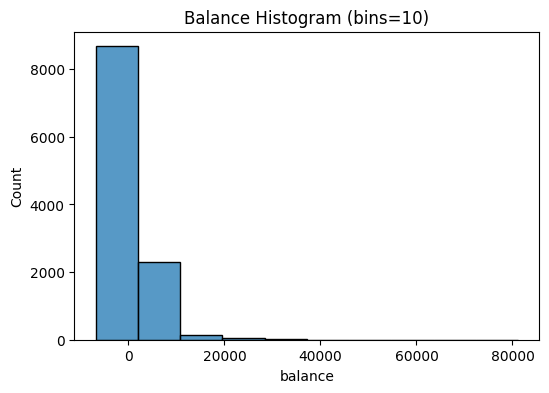

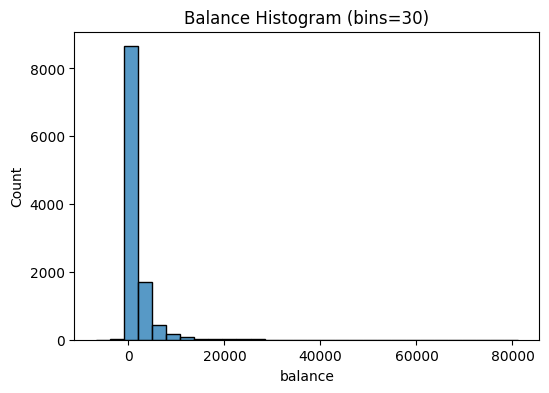

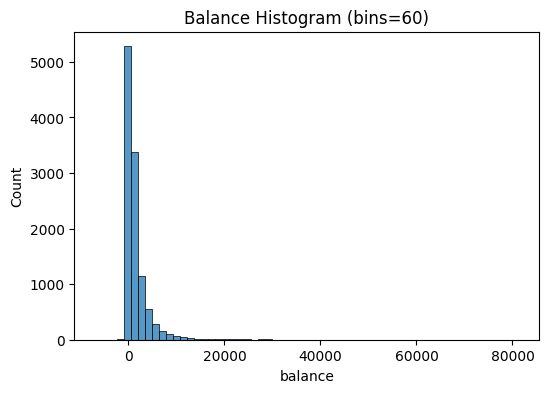

In [14]:
for bins in [10, 30, 60]:
    plt.figure(figsize=(6,4))
    sns.histplot(df["balance"], bins=bins)
    plt.title(f"Balance Histogram (bins={bins})")
    plt.xlabel("balance")
    plt.show()

Conclusions (What I learned from univariate analysis)

I analyzed numerical variables (age, balance, day, duration, campaign, pdays, previous) using histograms, KDE plots, violin plots, and boxplots, and I analyzed categorical variables using bar plots.

Overall distribution shapes

Age is slightly right-skewed. Most customers cluster around middle ages (min ≈ 18, max ≈ 95).

Balance is strongly right-skewed, meaning most customers have relatively low balances, but a small number have extremely high balances. Balance also includes negative values, which is realistic (e.g., overdrafts).

Duration is right-skewed, with many short calls and fewer very long calls.

Campaign, pdays, and previous are also highly skewed, with many low values and a few larger outliers.

Outliers
Boxplots show noticeable outliers, especially for:

balance (very high values far from the median)

duration (very long calls)

campaign (some customers contacted many times)

These outliers are expected in real-world marketing data but may require preprocessing later (log transform, clipping, robust scaling).

Grouped histograms (by deposit yes/no)
When comparing distributions by the conversion outcome (deposit):

Duration differs strongly across groups: customers who converted (“yes”) tend to have longer call durations than those who did not (“no”). This suggests duration may be a strong predictor of conversion.

Balance shows some separation, with converters having somewhat higher balances on average, though there is overlap.

Minimum/maximum values
Each histogram includes min/max values shown in the summary stats table. Some variables (like balance and pdays) have wide ranges, which matches expectations for bank and campaign history data.

Effect of bin size
Changing bin widths changes how much detail the histogram reveals:

Fewer bins (e.g., 10) creates a smoother, simpler view but can hide patterns.

More bins (e.g., 60) shows more detail but can look noisy.
Using multiple bin sizes helped confirm that balance and duration are truly skewed (not just a binning artifact).

Usability of data
Overall, the dataset appears usable and realistic for a Marketing Conversion Propensity project. The presence of skewness and outliers is expected for banking and marketing data. With basic preprocessing, it should work well for supervised modeling (classification), especially since the dataset includes a clear binary target (deposit yes/no).

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

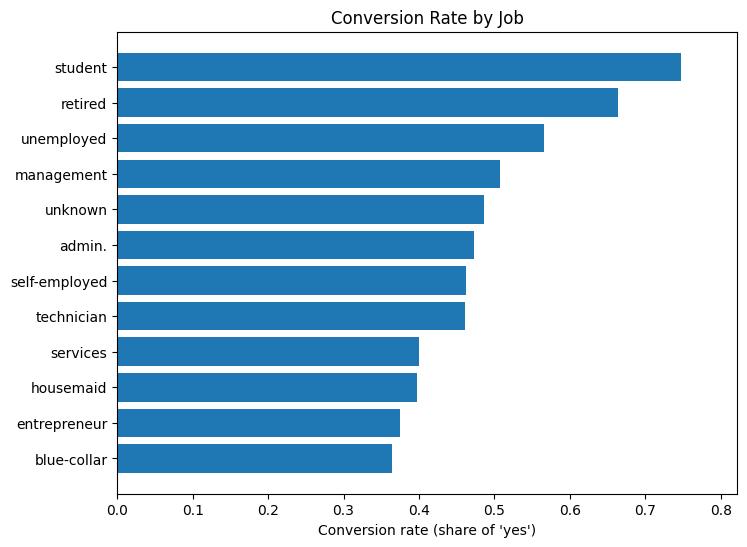

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load (if not already loaded)
df = pd.read_csv("bank.csv")
df.columns = df.columns.str.strip().str.lower()

# Ensure target is named "deposit" (your file)
# If your target column is different, print(df.columns) and adjust here
target_col = "deposit"

# conversion rate by job
job_rate = (df[target_col].astype(str).str.lower().eq("yes")
            .groupby(df["job"])
            .mean()
            .sort_values())

plt.figure(figsize=(8, 6))
plt.barh(job_rate.index, job_rate.values)
plt.title("Conversion Rate by Job")
plt.xlabel("Conversion rate (share of 'yes')")
plt.ylabel("")
plt.xlim(0, max(job_rate.values) * 1.1)
plt.show()

This chart is a simple horizontal bar chart sorted by value, which makes it easy to compare categories without clutter. Sorting supports quick pattern recognition, and the horizontal layout improves readability for long category names. This matches Storytelling with Data guidance for using bars when comparing magnitudes across categories and for reducing cognitive load by ordering the data.